# Cascadia Texture Building

In this notebook we use Python Image Library to build the texture for Cascadia that will be used in Shellpower.

To start, I've hand-drawn an image of a 125x125mm cell and this will be copy-pasted to form panels and then the whole top shell.

> Note: Usually I refrain from naming a document 'final', but the plug has already been ordered so the array layout is now locked in as of 2026-05-16

## Basic unit: the cell

This has been modified since the previous version, to correct the gap between cells from 1mm to 2mm.

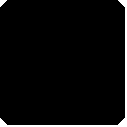

## Reference Images

[Final Array Geometry Measurements](https://ubcsolar26.monday.com/boards/9565353662/pulses/10058358397/posts/5199682336)

## Imports

In [1]:
from PIL import Image
import os; import sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from pathlib import Path

In [2]:
background_color = (255, 255, 255)  # rgb

def set_color(
    cell_img: Image.Image,
    color: tuple[int, int, int],
    replace_color: tuple[int, int, int] | None = None
) -> None:
    """Replaces pixels matching replace_color with color (mutates image in place)."""
    if replace_color is None:
        replace_color = (0, 0, 0, 255)

    # Assumes cell_img is already RGB
    pixels = cell_img.load()
    width, height = cell_img.size

    for x in range(width):
        for y in range(height):
            if pixels[x, y] == replace_color:
                pixels[x, y] = color

def build_panel(geometry: NDArray, cell_img: Image.Image, rg_pair: tuple[int, int], blue_offset=0) -> Image.Image:
    """Build a panel image by tiling cells according to a boolean array

    :param geometry: 2d boolean array, indexed by (x, y). 1 if there is a cell at the given coordinate.
    :param cell_img: Cell image to tile over the geometry
    :param rg_pair: Red/green colour channel value pair, used to distinguish cells.
    """
    # Determine shape of output image
    cell_w, cell_h = cell_img.size
    panel_cw, panel_ch = geometry.shape
    panel_w = panel_cw * cell_h
    panel_h = panel_ch * cell_w

    panel_img: Image.Image = Image.new('RGB', (panel_w, panel_h), color=background_color)

    it = np.nditer(geometry, flags=['multi_index'])
    for cell_bool in it:
        if not cell_bool:
            continue
        x, y = it.multi_index
        cell_loc = (x * cell_h, y * cell_w)

        colored_cell = cell_img.copy()

        r = rg_pair[0]
        g = rg_pair[1]
        b = it.iterindex + blue_offset
        set_color(colored_cell, (r, g, b))

        panel_img.paste(colored_cell, cell_loc)

    # remove extra 2mm spacing on bottom/right edge
    panel_cropped = panel_img.crop((0, 0, panel_w - 2, panel_h - 2))

    return panel_cropped

assets_path: Path = Path(r"C:\Users\Jonah\Documents\UBCSolar\2025\shellpower\optimizer\texture_builder\assets")

cell_img_path: Path = assets_path / "maxeon_127mm_padded_oneside.png"

In [3]:
p1_geom = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]).T
p2_geom = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
]).T
p3_geom = np.array([
    [1, 1, 1],
    [0, 0, 1],
    [0, 0, 1]
]).T
p4_geom = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
]).T
p5_geom = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]).T
p6_geom = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]).T


panel_geoms = (p1_geom, p2_geom, p3_geom, p4_geom, p5_geom, p6_geom)
for i, p in enumerate(panel_geoms):
    print(i, np.count_nonzero(p))


# assert  == 386
sum([np.count_nonzero(p) for p in panel_geoms])

0 76
1 65
2 5
3 88
4 76
5 76


np.int64(386)

In [4]:
panels: list[Image.Image] = []
rg_pairs = [
    (255, 127),
    (127, 0),
    (127, 128), # Do not make same (might be grayscale)
    (0, 127),
    (127, 255),
    (63, 0),
] # Note: use odd numbers, since even numbers could potentially result in rgb being grayscale and interpreted as bg

cell_img_path = r"C:\Users\Jonah\Documents\UBCSolar\2025\shellpower\optimizer\texture_builder\assets\maxeon_127mm_padded_oneside.png"
for i, (panel_geom, rg_pair) in enumerate(zip(panel_geoms, rg_pairs)):
    with Image.open(cell_img_path) as cell_img:
        if i == 1:
            blue_offset = 0
        elif i == 2:
            blue_offset = 70
        elif i == 3:
            blue_offset = 80
        else:
            blue_offset = 0
        panel = build_panel(panel_geom, cell_img, rg_pair, blue_offset=blue_offset)
        panels.append(panel)

        panel_img_path: Path = assets_path / f"panel{i+1}.png"

        panel.save(panel_img_path)
        panel.show() # uncomment to show previews

See https://ubcsolar26.monday.com/boards/9565353662/pulses/10058358397/posts/5199682336 for screenshots of panel corner locations for positioning reference.

In [13]:
# panel_x_z measured from SOLIDWORKS.
# +x is towards port (left) side, +z is toward front of car

# coordinates of top left vertex for all panels
# (top left when car is oriented with the front to the right)

# (0, 0) is as defined in solidworks / AllPanels.SLDASM as of 2026-05-23

panel_x_z: list[tuple[int, int]] = [
    (846-16, -2201+16),
    (453-16, -1407+16),
    (866-16, -1407+16),
    (144-16, -486+16),
    (804-16, 816+16),
    (720-16, 1610+16),
]

# mm / px
car_width: int = 1906
car_length: int = 4882
texture_size = (car_length, car_width)

offset_x, offset_z = (-100, -250)
center = (car_width//2 + offset_x, car_length//2 + offset_z,)

# Distance from image (top, left) for top left corner of each panel
panel_top_lefts: list[tuple[int, int]] = [
    (center[1] + z, center[0] - x)
    for (x, z) in panel_x_z
]

panel_layout: list[dict] = [
    {
        'name': 'panel 1',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': panel_top_lefts[0],
        'image': panels[0],
    },
    {
        'name': 'panel 2',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': panel_top_lefts[1],
        'image': panels[1],
    },
    {
        'name': 'panel 3',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': panel_top_lefts[2],
        'image': panels[2],
    },
    {
        'name': 'panel 4',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': panel_top_lefts[3],
        'image': panels[3],
    },
    {
        'name': 'panel 5',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': panel_top_lefts[4],
        'image': panels[4],
    },
    {
        'name': 'panel 6',
        'rotation_ccw' : Image.Transpose.ROTATE_90,
        'top_left': panel_top_lefts[5],
        'image': panels[5],
    },
]

texture_img: Image.Image = Image.new('RGB', texture_size, color=background_color)

for panel in panel_layout:
    print(f"Placing panel {panel['name']}")

    panel_w, panel_h = panel['image'].size

    rotated_panel = panel['image'].copy().transpose(panel['rotation_ccw'])

    texture_img.paste(rotated_panel, panel['top_left'])

texture_img.show()

Placing panel panel 1
Placing panel panel 2
Placing panel panel 3
Placing panel panel 4
Placing panel panel 5
Placing panel panel 6


In [14]:
pixels = texture_img.get_flattened_data()

non_white_count = sum(1 for p in pixels if p != (255, 255, 255))

print(f"Total black pixel area: {non_white_count / 1e6} m^2")

Total black pixel area: 5.988018 m^2


In [15]:
texture_img.save(
    assets_path / "cascadia_2026-05-23.png",
    format="PNG",
)

In [ ]:
# texture_img.transpose(Image.Transpose.ROTATE_180)
# texture_img.save(
#     assets_path / "cascadia_v1_180.png",
#     format="PNG",
# )

## Transpose the image

Leftmost point
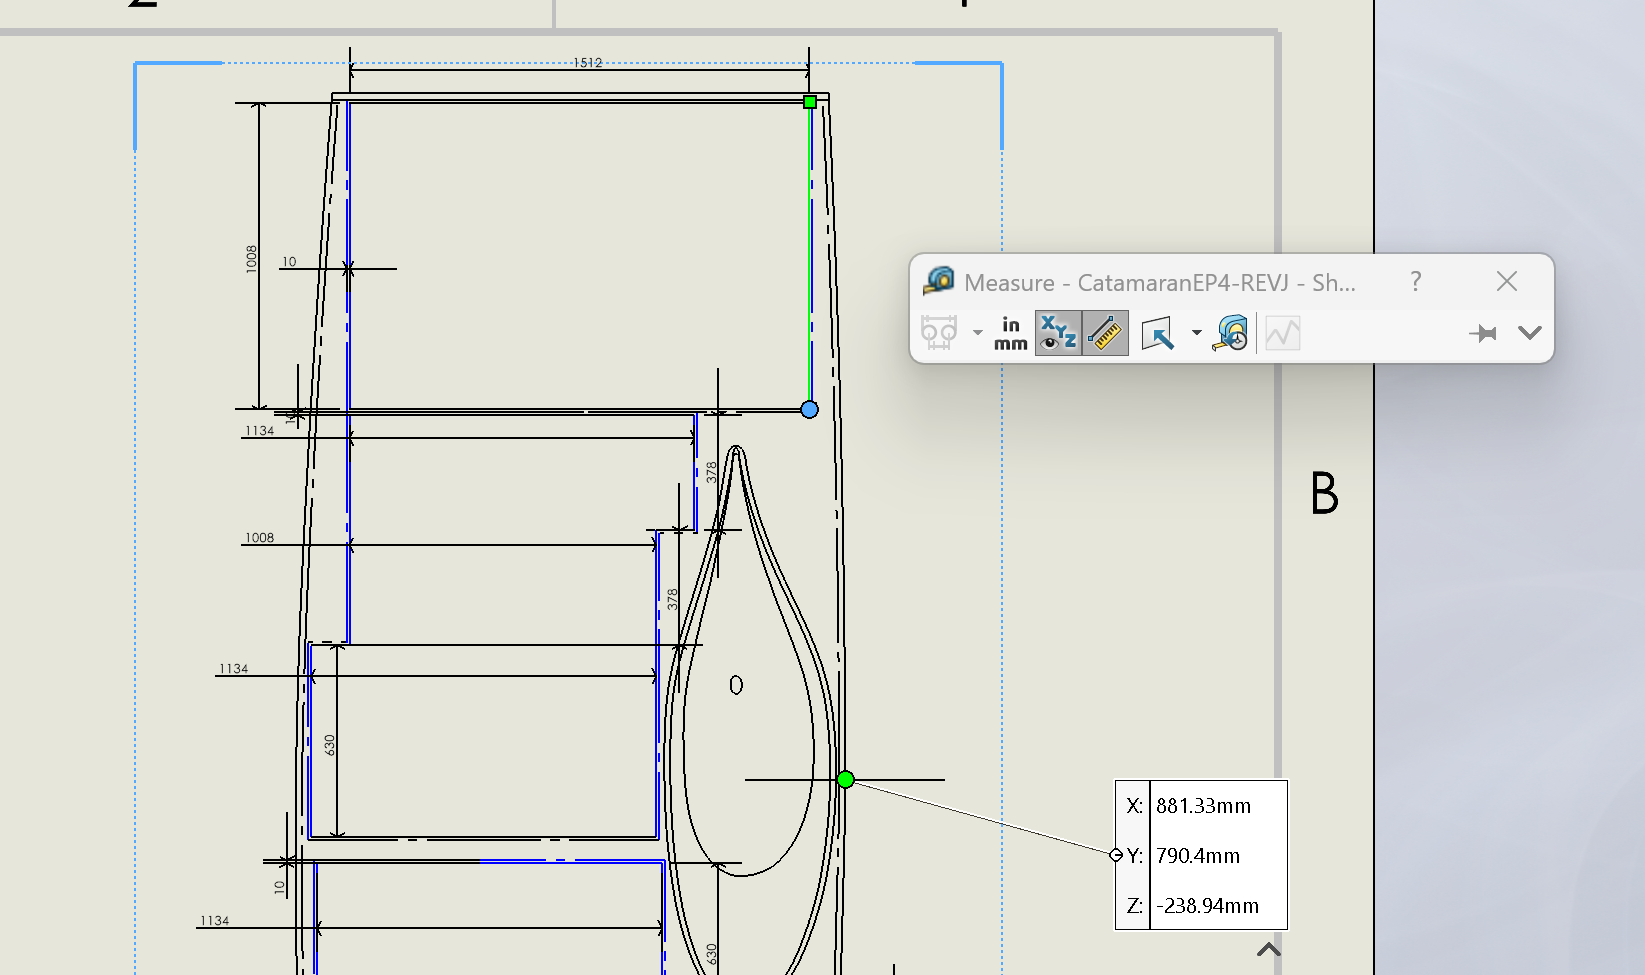

Back left of arrays
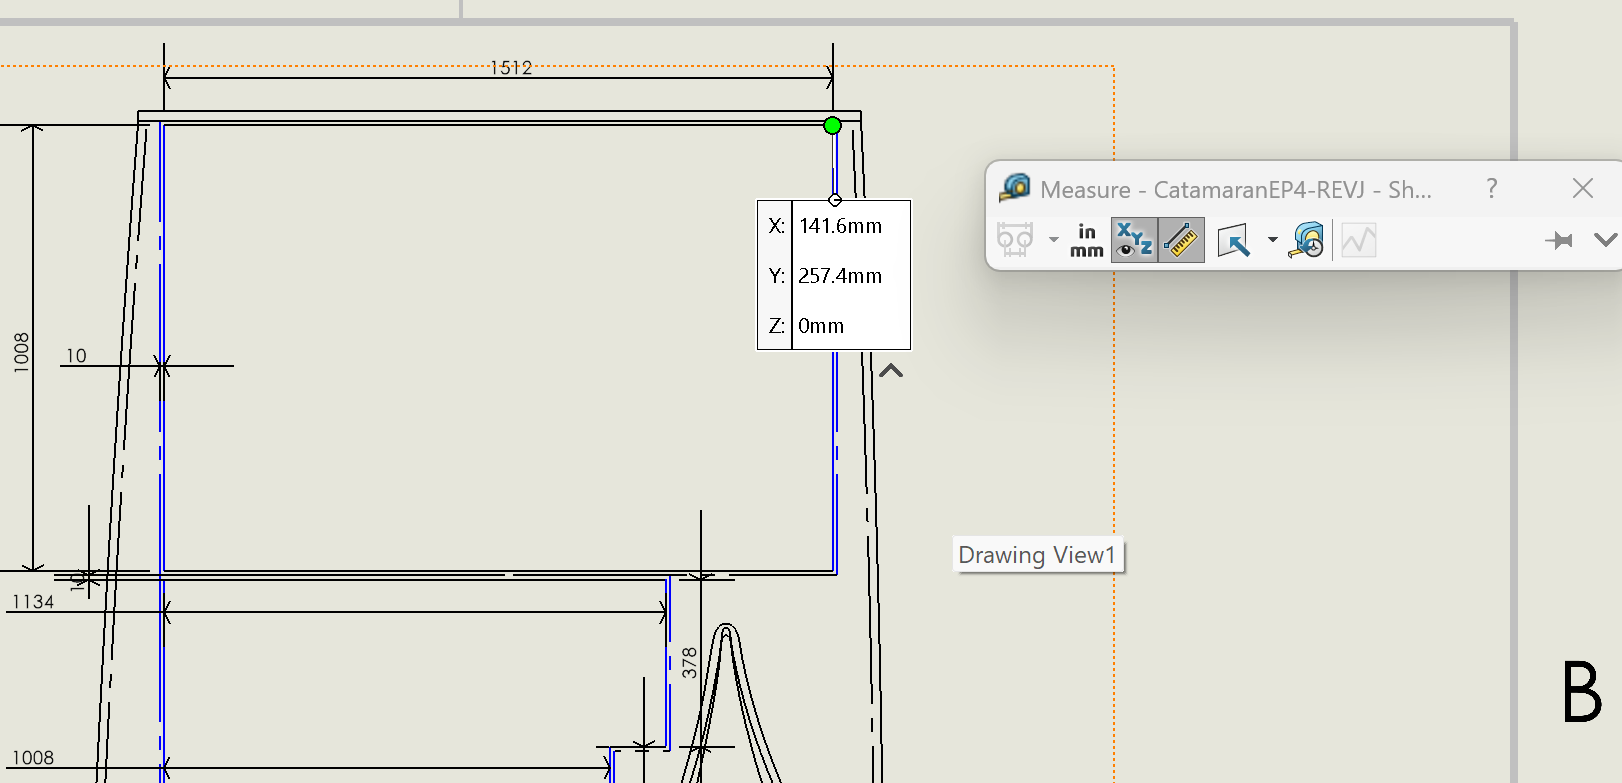

Back of topshell
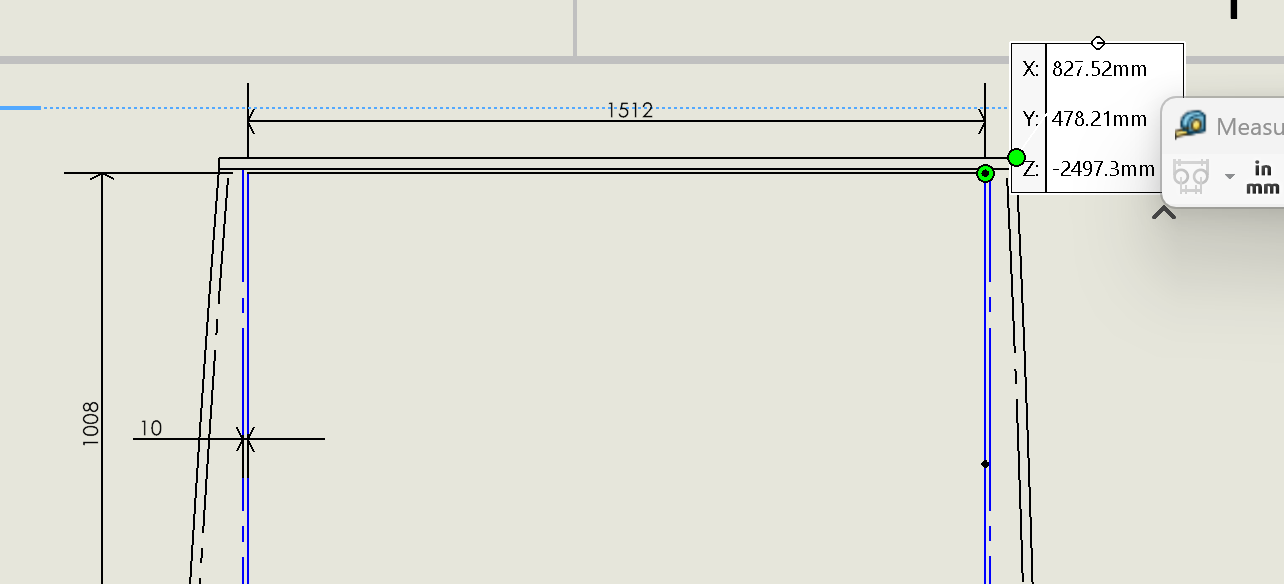

In [ ]:
# right and forward relative to the driver of the car
transpose_right = 160
transpose_forward = 90

def pad_origin(img: Image.Image, pad_x: int = 0, pad_y: int = 0, fill="white") -> Image.Image:
    """
    Pad an image on the top and left sides only (near origin).

    :param img: PIL Image
    :param pad_x: pixels to add on the left (x direction)
    :param pad_y: pixels to add on the top (y direction)
    :param fill: background color (default white)
    :return: padded PIL Image
    """

    new_width = img.width + pad_x
    new_height = img.height + pad_y

    # Create background with same mode
    new_img = Image.new(img.mode, (new_width, new_height), fill)

    # Paste original shifted right/down
    new_img.paste(img, (pad_x, pad_y))

    return new_img

transposed_img = pad_origin(texture_img, pad_x=transpose_forward, pad_y=transpose_right)
transposed_img.show()
transposed_img.save(
    assets_path / f"cascadia_v1_y{transpose_right}x{transpose_forward}.png",
    format="PNG",
)

In [ ]:
_

np.int64(386)